## Importowanie bibliotek


In [3]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)
sns.set(font_scale=1.3)
sklearn.__version__

'1.6.1'

##Wygenerowanie danych

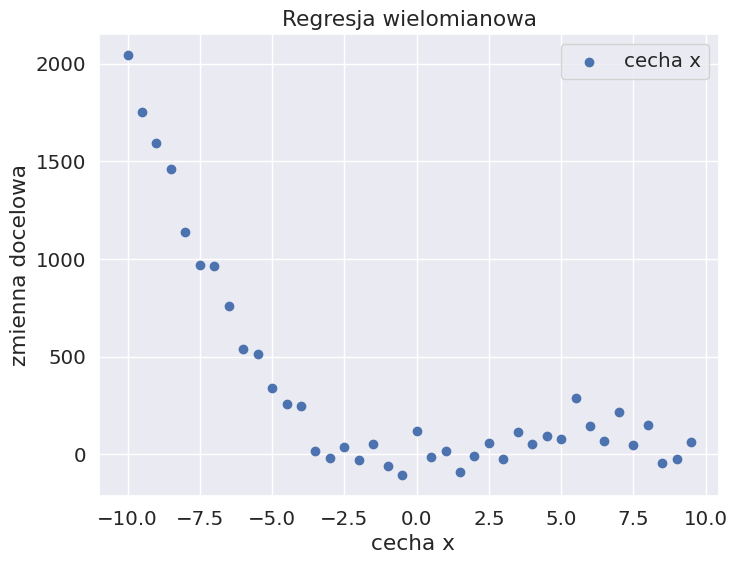

In [4]:
X = np.arange(-10,10,0.5)
noise = 80  * np.random.randn(40)
y = -X**3 + 10*X**2 + 3 + noise
X = X.reshape(-1,1)


plt.figure(figsize=(8,6))
plt.title('Regresja wielomianowa')
plt.xlabel(' cecha x')
plt.ylabel('zmienna docelowa')
plt.scatter(X,y, label = 'cecha x')
plt.legend()
plt.show()

## Model liniowy

In [5]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X,y)

LinearRegression()

In [6]:
print(f'R2 SCORE: {regressor.score(X, y)}')

R2 SCORE: 0.5199083375158753


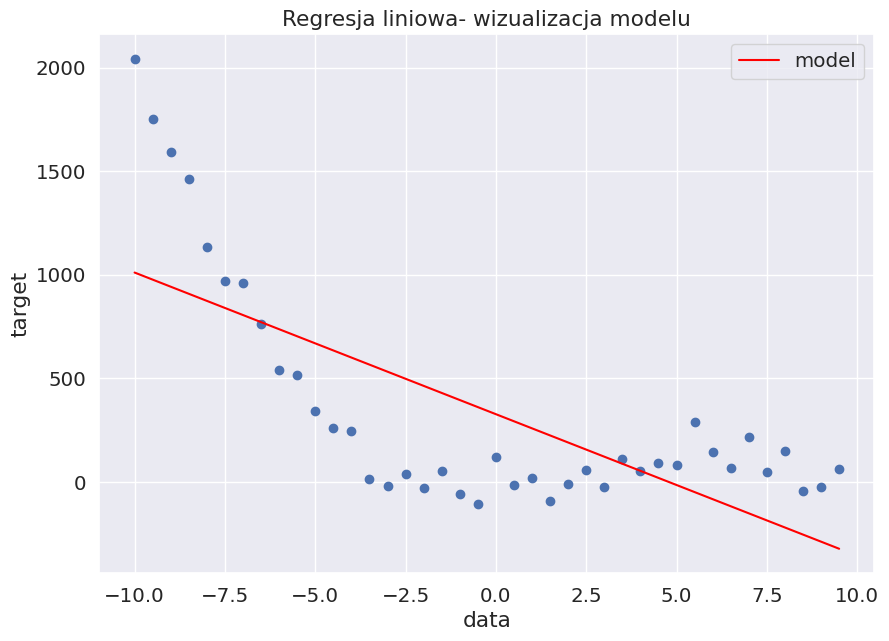

In [7]:
plt.figure(figsize=(10,7))
plt.title('Regresja liniowa- wizualizacja modelu')
plt.ylabel('target')
plt.xlabel('data')
plt.scatter(X, y)
plt.plot(X, regressor.predict(X), color='red', label = 'model')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics  import r2_score
r2_score(y, regressor.predict(X))

0.5199083375158753

## Ekstrakcja cech wielomianowych - stopień 2

In [9]:
df = pd.DataFrame(data={'X': X.ravel()})
df.head(10)

,X
0,-10.0
1,-9.5
2,-9.0
3,-8.5
4,-8.0
5,-7.5
6,-7.0
7,-6.5
8,-6.0
9,-5.5


In [10]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
X_poly[:5]

array([[  1.  , -10.  , 100.  ],
       [  1.  ,  -9.5 ,  90.25],
       [  1.  ,  -9.  ,  81.  ],
       [  1.  ,  -8.5 ,  72.25],
       [  1.  ,  -8.  ,  64.  ]])

In [11]:
X_poly.shape

(40, 3)

## Dopasowanie modelu  2 st

In [12]:
regressor_poly = LinearRegression()
regressor_poly.fit(X_poly,y)

LinearRegression()

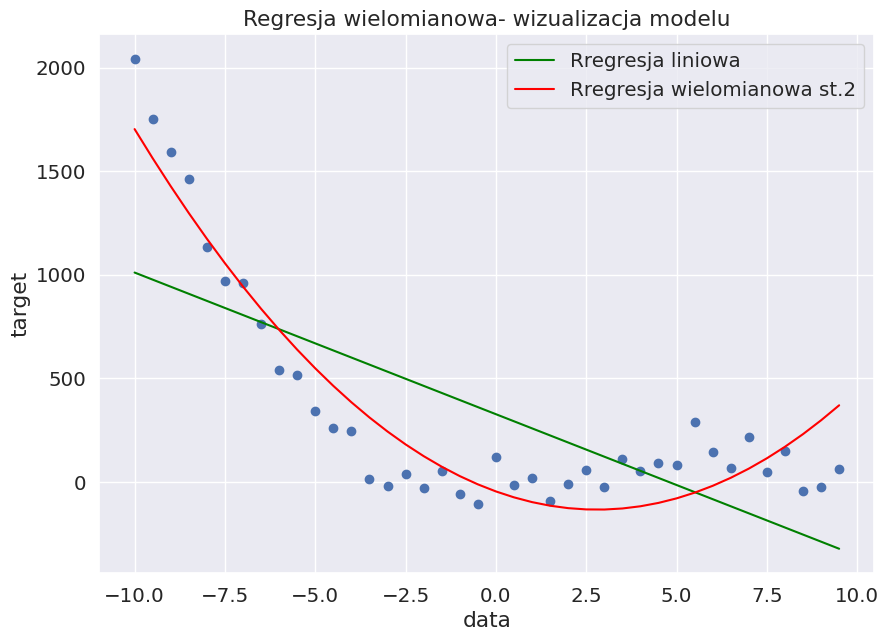

In [17]:
plt.figure(figsize=(10,7))
plt.title('Regresja wielomianowa- wizualizacja modelu')
plt.ylabel('target')
plt.xlabel('data')
plt.scatter(X, y)
plt.plot(X ,regressor.predict(X), color='green', label = 'Rregresja liniowa')
plt.plot(X ,regressor_poly.predict(X_poly), color='red', label = 'Rregresja wielomianowa st.2')
plt.legend()
plt.show()

In [18]:
r2_score(y,regressor_poly.predict(X_poly))

0.8918791591334647

##Ekstrakcja cech wielomianowych - stopień 3

In [20]:
poly_features = PolynomialFeatures(degree=3)
X_poly_3 = poly_features.fit_transform(X)
X_poly_3[:5]

array([[    1.   ,   -10.   ,   100.   , -1000.   ],
       [    1.   ,    -9.5  ,    90.25 ,  -857.375],
       [    1.   ,    -9.   ,    81.   ,  -729.   ],
       [    1.   ,    -8.5  ,    72.25 ,  -614.125],
       [    1.   ,    -8.   ,    64.   ,  -512.   ]])



## Dopasowanie modelu 3 st

In [23]:
regressor_poly3 = LinearRegression()
regressor_poly3.fit(X_poly_3,y)

LinearRegression()

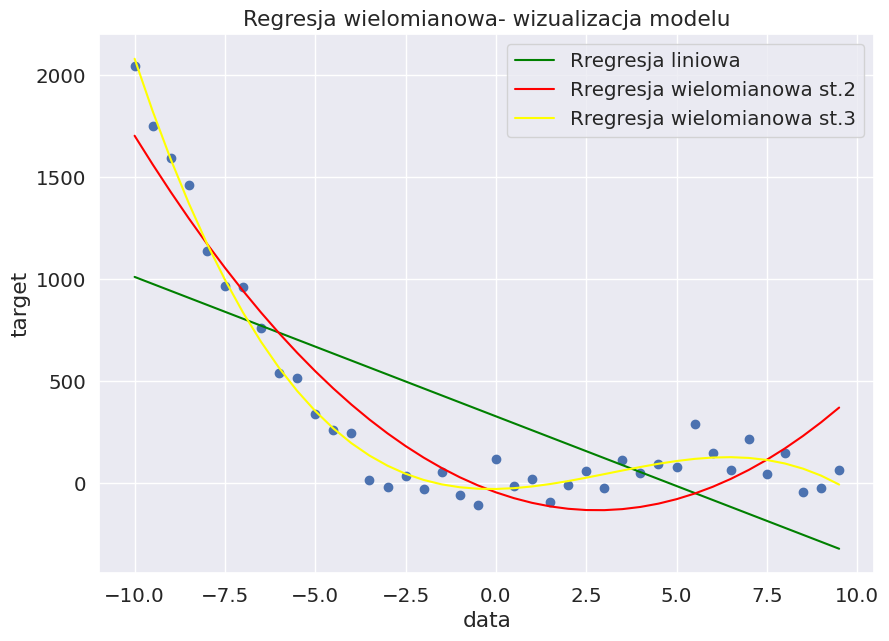

In [26]:
plt.figure(figsize=(10,7))
plt.title('Regresja wielomianowa- wizualizacja modelu')
plt.ylabel('target')
plt.xlabel('data')
plt.scatter(X, y)
plt.plot(X ,regressor.predict(X), color='green', label = 'Rregresja liniowa')
plt.plot(X ,regressor_poly.predict(X_poly), color='red', label = 'Rregresja wielomianowa st.2')
plt.plot(X ,regressor_poly3.predict(X_poly_3), color='yellow', label = 'Rregresja wielomianowa st.3')
plt.legend()
plt.show()

In [27]:
r2_score(y,regressor_poly3.predict(X_poly_3))

0.9836823092151372

## porownanie metryk

In [30]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score as r2


In [33]:
results  = pd.DataFrame(data = {
    'r2_score': [r2(y,regressor.predict(X)),r2(y,regressor_poly.predict(X_poly)),r2(y,regressor_poly3.predict(X_poly_3))],
    'mae' :  [mae(y,regressor.predict(X)),mae(y,regressor_poly.predict(X_poly)),mae(y,regressor_poly3.predict(X_poly_3))],
    'mse' :  [mse(y,regressor.predict(X)),mse(y,regressor_poly.predict(X_poly)),mse(y,regressor_poly3.predict(X_poly_3))],
    'rmse' :  [np.sqrt(mse(y,regressor.predict(X))),np.sqrt(mse(y,regressor_poly.predict(X_poly))),np.sqrt(mse(y,regressor_poly3.predict(X_poly_3)))]
})
results


,r2_score,mae,mse,rmse
0,0.519908,316.267126,143775.153332,379.176942
1,0.891879,155.977929,32379.421866,179.942829
2,0.983682,57.572030,4886.730343,69.905152
